<a href="https://colab.research.google.com/github/PatilVaishnav131/disease-prediction-ai/blob/main/Brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# 1. Mount Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ================================
# 2. Extract Dataset
# ================================
import zipfile
import os

# Dataset path
zip_path = "/content/drive/MyDrive/brain_tumor/archive(2).zip"
extract_path = "/content/brain_tumor_dataset"

# Extract only if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Dataset extracted at:", extract_path)


✅ Dataset extracted at: /content/brain_tumor_dataset


In [ ]:
# ================================
# 3. Import Libraries
# ================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os


In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Dense


In [ ]:
# ================================
# 4. Data Preprocessing
# ================================
train_dir = os.path.join(extract_path, "Training")
test_dir = os.path.join(extract_path, "Testing")

# # Data augmentation
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     zoom_range=0.2,
#     horizontal_flip=True
# )


train_gen = ImageDataGenerator(rescale=1./255, brightness_range=(0.8, 1.2))
valid_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="categorical"
)

valid_data = valid_gen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="categorical"
)
valid_data = valid_gen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode="categorical"
)



Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


Classes: ['notumor', 'glioma', 'meningioma', 'pituitary']
notumor         -> Training: 1595, Testing:  405
glioma          -> Training: 1321, Testing:  300
meningioma      -> Training: 1339, Testing:  306
pituitary       -> Training: 1457, Testing:  300


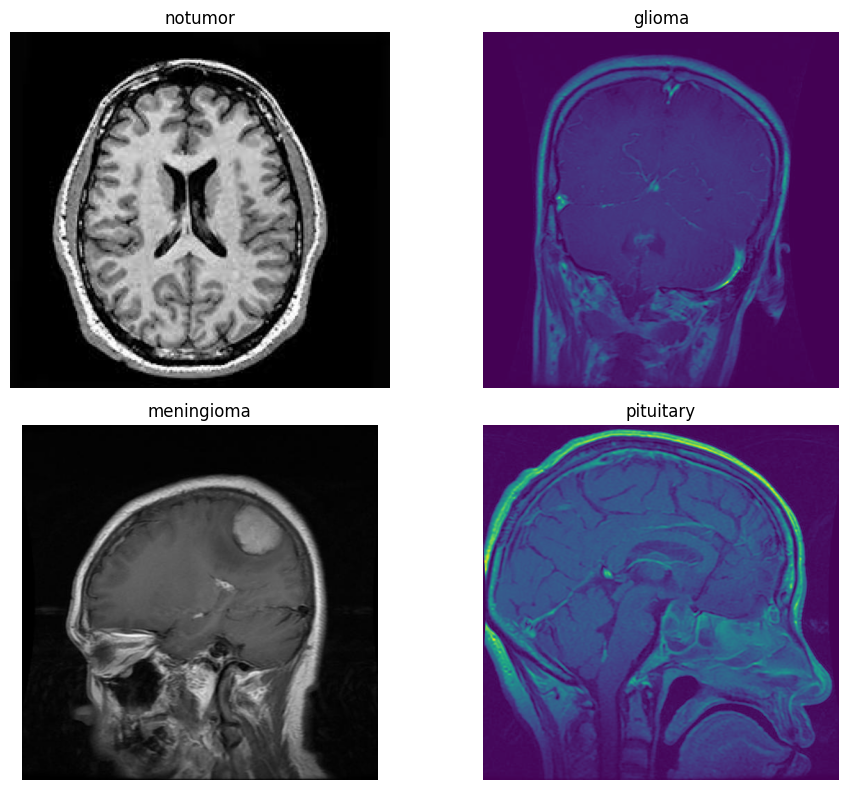

In [ ]:
# ================================
# Data Exploration
# ================================
import os
import matplotlib.pyplot as plt
import random

# Directories
train_dir = os.path.join(extract_path, "Training")
test_dir = os.path.join(extract_path, "Testing")

# Print class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Count images per class
for c in classes:
    train_count = len(os.listdir(os.path.join(train_dir, c)))
    test_count = len(os.listdir(os.path.join(test_dir, c)))
    print(f"{c:15s} -> Training: {train_count:4d}, Testing: {test_count:4d}")

# Show sample images
plt.figure(figsize=(10, 8))

for i, c in enumerate(classes):
    img_path = os.path.join(train_dir, c, random.choice(os.listdir(os.path.join(train_dir, c))))
    img = plt.imread(img_path)
    plt.subplot(2, 2, i+1)   # adjust (2,2) if you have 4 classes, change if more
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
base_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3),
    pooling="max"
)

# Freeze base model layers first
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.25),
    Dense(4, activation="softmax")
])



83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 189s 840ms/step - accuracy: 0.6463 - loss: 1.0371 - val_accuracy: 0.8482 - val_loss: 0.4088
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 310ms/step - accuracy: 0.8512 - loss: 0.4101 - val_accuracy: 0.8459 - val_loss: 0.3723
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 54s 303ms/step - accuracy: 0.8638 - loss: 0.3682 - val_accuracy: 0.8307 - val_loss: 0.4381
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 55s 306ms/step - accuracy: 0.8785 - loss: 0.3210 - val_accuracy: 0.8673 - val_loss: 0.3148
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 55s 305ms/step - accuracy: 0.8842 - loss: 0.2986 - val_accuracy: 0.8780 - val_loss: 0.3106
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 54s 304ms/step - accuracy: 0.9026 - loss: 0.2565 - val_accuracy: 0.9092 - val_loss: 0.2314
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 55s 305ms/step - accuracy: 0.9022 - loss: 0.2465 - val_accuracy: 0.9146 - val_loss: 0.2144
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 55s 306ms/step - accuracy: 0.9139 - loss: 

In [ ]:
base_model.trainable = True
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),  # smaller LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=5
)


Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.6848 - loss: 1.2250 - val_accuracy: 0.8009 - val_loss: 0.4707
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 164s 917ms/step - accuracy: 0.8961 - loss: 0.2860 - val_accuracy: 0.8268 - val_loss: 0.4432
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 163s 912ms/step - accuracy: 0.9241 - loss: 0.2000 - val_accuracy: 0.8802 - val_loss: 0.2907
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 163s 910ms/step - accuracy: 0.9421 - loss: 0.1548 - val_accuracy: 0.9405 - val_loss: 0.1595
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 173s 969ms/step - accuracy: 0.9624 - loss: 0.0970 - val_accuracy: 0.9580 - val_loss: 0.1193


In [ ]:
# ================================
# 7. Evaluate Model
# ================================
# Evaluate the trained model on test data
loss, acc = model.evaluate(valid_data)
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.9579 - loss: 0.1333
Test Accuracy: 95.80%
Test Loss: 0.1193


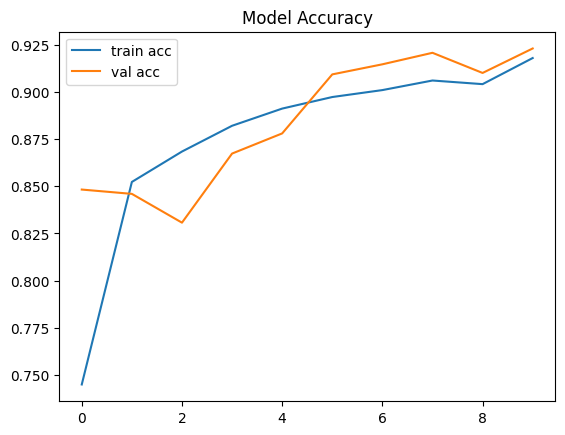

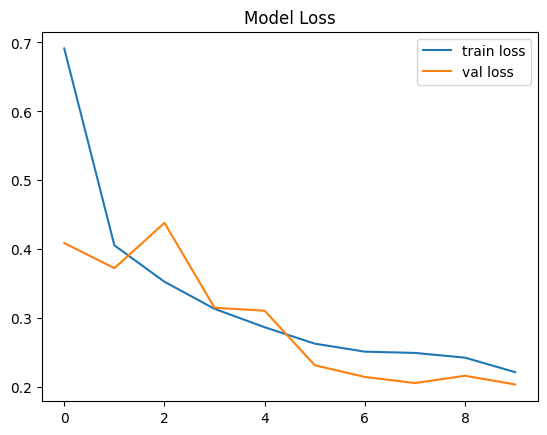

In [ ]:
# ================================
# 8. Plot Accuracy & Loss
# ================================
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Model Loss")
plt.show()


In [ ]:
# ================================
# 9. Make Predictions
# ================================
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Example test image path
img_path = os.path.join(test_dir, "glioma/Te-gl_0010.jpg")

# Load and preprocess the image
img = image.load_img(img_path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict class probabilities
prediction = model.predict(img_array)

# Get class labels from training generator
class_labels = list(train_data.class_indices.keys())

# Print predicted class
print("Predicted Class:", class_labels[np.argmax(prediction)])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Class: glioma


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


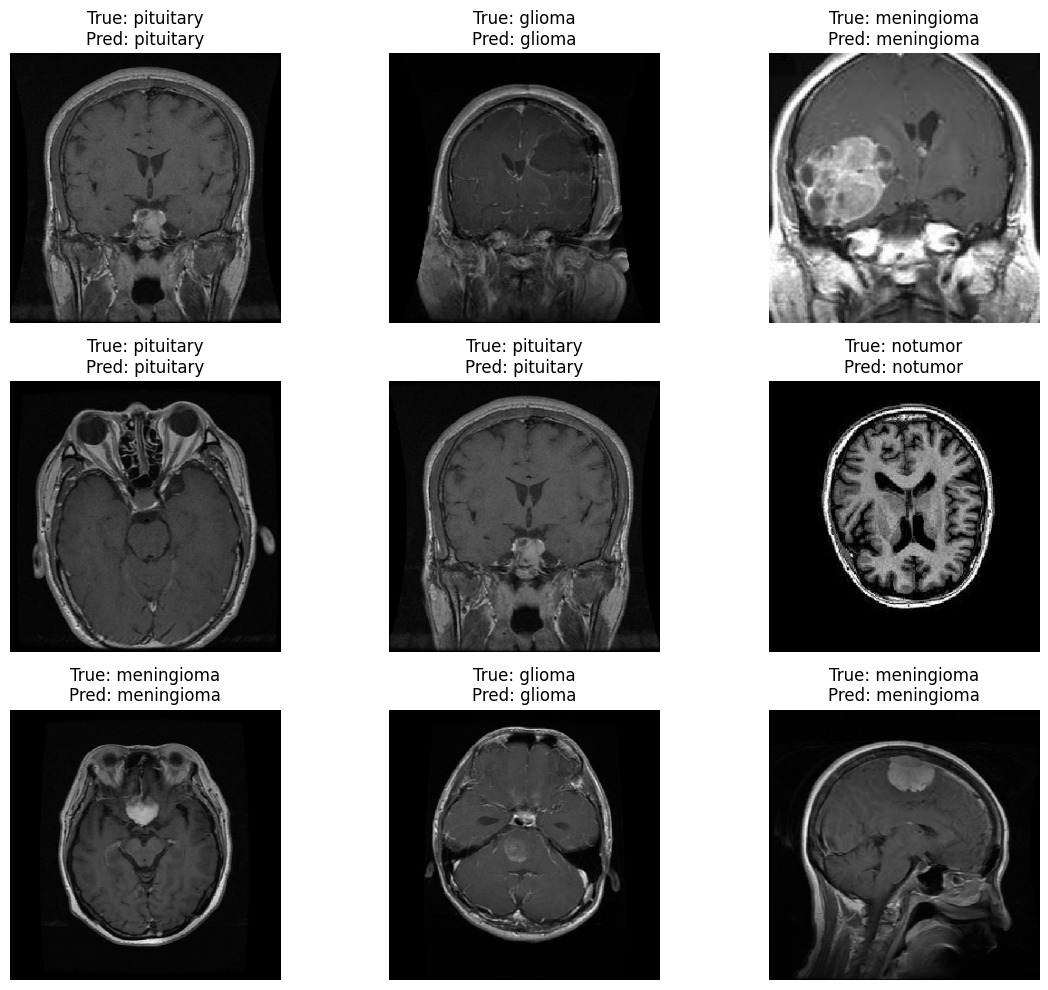

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import tensorflow as tf

# Use the valid_data/test generator as per previous setup
test_gen = valid_data  # Must be your actual test data generator (created from 'Testing' dir)
class_labels = list(test_gen.class_indices.keys())

plt.figure(figsize=(12, 10))
for i in range(9):
    idx = random.randint(0, len(test_gen.filenames)-1)
    img_path = os.path.join(test_gen.directory, test_gen.filenames[idx])

    # Load and preprocess the image
    img = tf.keras.utils.load_img(img_path, target_size=(299, 299))  # match model input size
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    pred_probs = model.predict(img_batch)
    pred_class = class_labels[np.argmax(pred_probs)]

    # True label (extracted from filename/flow_from_directory structure)
    true_class = img_path.split(os.sep)[-2]

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_class}\nPred: {pred_class}")

plt.tight_layout()
plt.show()


In [ ]:
model.save('/content/drive/MyDrive/brain_tumor/brain_tumor_detection_model.h5')
print("Model saved successfully in HDF5 format.")


Model saved successfully in HDF5 format.
